# Multistable functions
This tutorial demonstrates counting the number of Monotone Boolean Functions (MBFs) that support multistability between the single high states $(10\cdots0, 01\cdots0, \ldots, 00\cdots1)$ for fully connected networks with n nodes and m negative/inhibitory inputs. 

In [1]:
import numpy as np
import pandas as pd
import mbnet as mn

We consider the network to be fully connected with self-activations on each node. If a node does not have inputs from all the nodes, the size of MBF set varies, making comparison between them non-meaningful.

In [2]:
def adj_full(n,m):
    """
    Gives adjacency matrix of a fully connected network with self activations and inhibitions to node 0 from the first m.
    """
    adjmat = pd.DataFrame(np.ones((n,n),dtype=int))
    # for i in range(0,n):
    adjmat.loc[1:m,0] = -1
    return adjmat

## Demonstration on a 3-node network with 1 inhibition ($n = 3, m = 1$)

First we showcase the technique on $n = 3, m = 1$.

In [3]:
n = 3
m = 1

We construct a Boolean Lattice as shown.

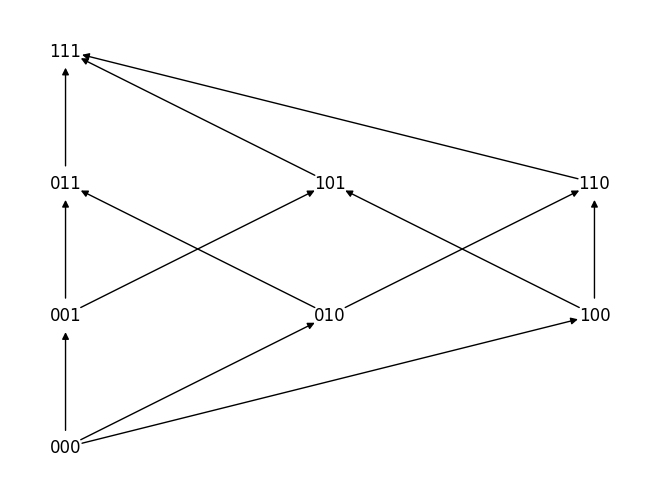

In [4]:
BL = mn.tl.lattice_B(n)
mn.pl.lattice(BL)

The adjacency matrix can be generated with 1 inhibition. This adjacency matrix helps tranform the single high states to inputs for positive MBFs using $T$. We consider the first node (0) for this case. The inputs also have to be converted to string as the Lattice nodes are represented as such.

In [5]:
A = adj_full(n,m)
A

,0,1,2
0,1,1,1
1,-1,1,1
2,1,1,1


In [6]:
sstate = pd.DataFrame(np.eye(n, dtype=int))
sstate

,0,1,2
0,1,0,0
1,0,1,0
2,0,0,1


In [7]:
inp, oup = mn.utils.T(A, sstate, 0)
inp = pd.DataFrame(inp).astype(str).sum(axis=1)

We can assign the output values of for each of the nodes correspoding to the inputs on the Lattice. Due to partial ordering of the lattice, we can propagate the outputs such that every vector below a vector with value 0 to also be 0 and every vector above every vector with value 1 to also be 1. This ensures that the function represented by this remains monotone.

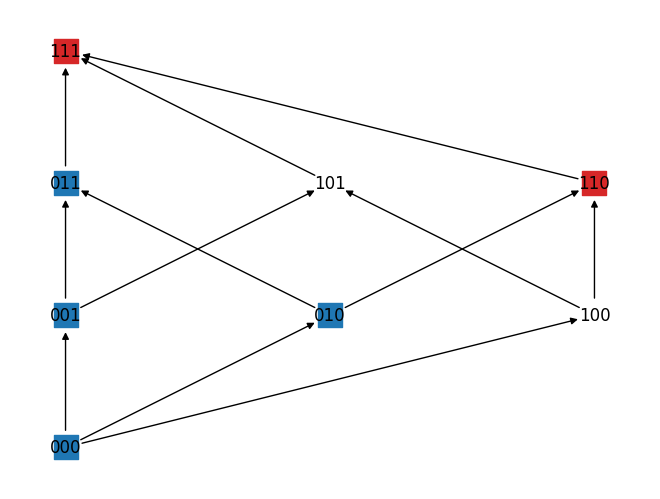

In [8]:
mn.tl.constraint_IO(BL, inp, oup)
mn.pl.lattice(BL)

We can see from the above plot that 2 nodes (vectors) remain unconstrained. While this puts an upper bound of $2^2 = 4$, one should note that monotonicity (via partial ordering) has to be maintained. We do this by generating combination of values for the top most layer, propagating values through the partial ordering and recursively performing this for nodes that remain unconstrained, to obtain the final count of number of multistable functions. 

In [9]:
mn.tl.unconstrained_count(BL)

3

## Table across multiple values of n

We can loop over multiple values of $n$ and $m \in \{0,1,\cdots,n-1\}$ to obtain the values in Table 2 of the manuscript.

In [10]:
n_min = 3
n_max = 5

In [11]:
Wi = []
for n in range(n_min, n_max+1):
    BL = mn.tl.lattice_B(n)
    sstate = pd.DataFrame(np.eye(n, dtype=int))
    for m in range(0,n):
        BLi = BL.copy()
        A = adj_full(n,m)
        inp, oup = mn.utils.T(A,sstate,0)
        inp = pd.DataFrame(inp).astype(str).sum(axis=1)
        mn.tl.constraint_IO(BLi,inp, oup)
        counts = mn.tl.unconstrained_count(BLi)
        Wi.append([n,m,counts])


In [12]:
Wi = pd.DataFrame(Wi, columns=['n','m','|Wi|'])
Wi

,n,m,|Wi|
0,3,0,2
1,3,1,3
2,3,2,10
3,4,0,9
4,4,1,17
5,4,2,14
6,4,3,38
7,5,0,114
8,5,1,575
9,5,2,445
